In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import os

os.chdir('/Users/syedamishrasaiara/pythonprojects/SQL_Analytics')
DATA = "data/yellow_tripdata_2024-01.parquet"
os.makedirs('charts', exist_ok=True)
print("Ready!")

Ready!


## Time Pattern Analysis — NYC Yellow Taxi (January 2024)
When do New Yorkers take taxis? This notebook breaks down demand 
across hours, days, and weeks using time-series SQL techniques.

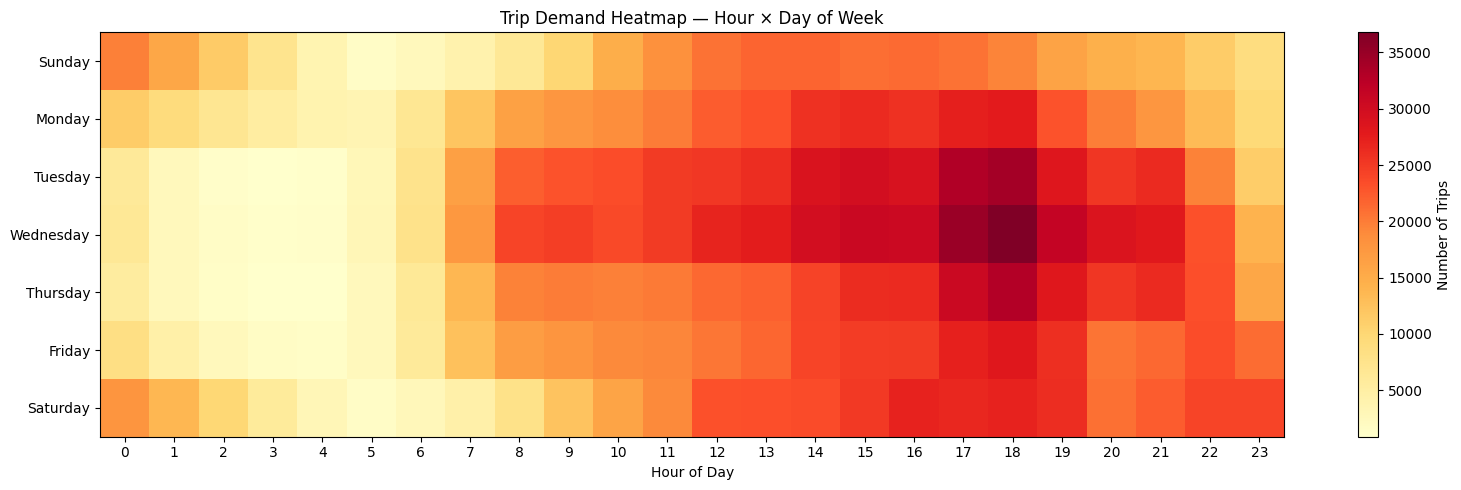

In [2]:
#Heatmap data: hour × day of week
heatmap_data = duckdb.sql(f"""
    SELECT
        DAYNAME(tpep_pickup_datetime) AS day_name,
        DAYOFWEEK(tpep_pickup_datetime) AS day_num,
        EXTRACT(HOUR FROM tpep_pickup_datetime) AS hour,
        COUNT(*) AS trips
    FROM '{DATA}'
    WHERE fare_amount > 0 AND trip_distance > 0
    GROUP BY day_name, day_num, hour
    ORDER BY day_num, hour
""").df()

# Pivot for heatmap
pivot = heatmap_data.pivot(index='day_name', columns='hour', values='trips')
day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
pivot = pivot.reindex(day_order)

import numpy as np
plt.figure(figsize=(16, 5))
plt.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Number of Trips')
plt.xticks(range(24), range(24))
plt.yticks(range(7), day_order)
plt.xlabel('Hour of Day')
plt.title('Trip Demand Heatmap — Hour × Day of Week')
plt.tight_layout()
plt.savefig('charts/demand_heatmap.png', dpi=150)
plt.show()

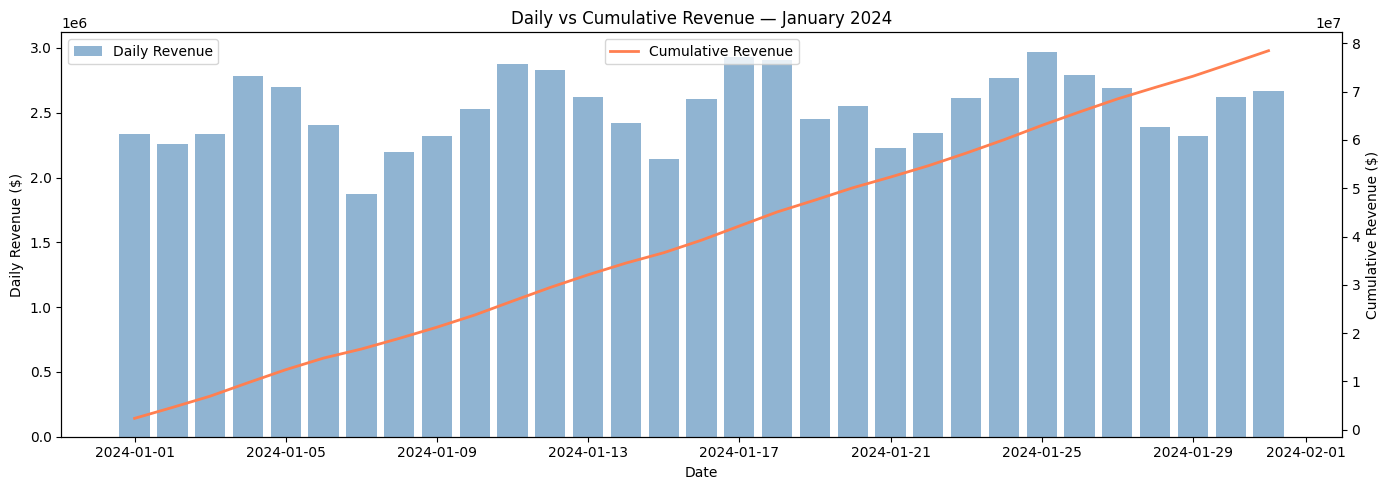

Month total revenue: $78,481,619
Avg daily revenue: $2,531,665


In [5]:
#Daily revenue with running total (window function) 
running = duckdb.sql(f"""
    WITH daily_rev AS (
        SELECT
            DATE(tpep_pickup_datetime) AS trip_date,
            COUNT(*) AS daily_trips,
            ROUND(SUM(total_amount), 2) AS daily_revenue
        FROM '{DATA}'
        WHERE fare_amount > 0
          AND trip_distance > 0
          AND tpep_pickup_datetime >= '2024-01-01'
          AND tpep_pickup_datetime < '2024-02-01'
        GROUP BY trip_date
    )
    SELECT
        trip_date,
        daily_trips,
        daily_revenue,
        ROUND(SUM(daily_revenue) OVER (ORDER BY trip_date), 2) AS cumulative_revenue
    FROM daily_rev
    ORDER BY trip_date
""").df()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(running['trip_date'], running['daily_revenue'], color='steelblue', alpha=0.6, label='Daily Revenue')
ax2 = ax1.twinx()
ax2.plot(running['trip_date'], running['cumulative_revenue'], color='coral', linewidth=2, label='Cumulative Revenue')
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Revenue ($)')
ax2.set_ylabel('Cumulative Revenue ($)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
plt.title('Daily vs Cumulative Revenue — January 2024')
plt.tight_layout()
plt.savefig('charts/revenue_over_time.png', dpi=150)
plt.show()

print(f"Month total revenue: ${running['daily_revenue'].sum():,.0f}")
print(f"Avg daily revenue: ${running['daily_revenue'].mean():,.0f}")

In [4]:
# Peak vs off-peak comparison
peak = duckdb.sql(f"""
    SELECT
        CASE
            WHEN EXTRACT(HOUR FROM tpep_pickup_datetime) BETWEEN 7 AND 9 THEN 'Morning Rush (7–9am)'
            WHEN EXTRACT(HOUR FROM tpep_pickup_datetime) BETWEEN 17 AND 19 THEN 'Evening Rush (5–7pm)'
            WHEN EXTRACT(HOUR FROM tpep_pickup_datetime) BETWEEN 22 AND 23
              OR EXTRACT(HOUR FROM tpep_pickup_datetime) BETWEEN 0 AND 2 THEN 'Late Night (10pm–2am)'
            ELSE 'Off-Peak'
        END AS time_period,
        COUNT(*) AS trips,
        ROUND(AVG(fare_amount), 2) AS avg_fare,
        ROUND(AVG(trip_distance), 2) AS avg_distance
    FROM '{DATA}'
    WHERE fare_amount > 0 AND trip_distance > 0
    GROUP BY time_period
    ORDER BY trips DESC
""").df()

peak 

,time_period,trips,avg_fare,avg_distance
0,Off-Peak,1560883,18.75,3.80
1,Evening Rush (5–7pm),585346,17.59,3.02
2,Late Night (10pm–2am),403543,19.13,3.69
3,Morning Rush (7–9am),319942,18.12,4.74


## Key Findings

- **Heatmap reveals**: Tuesday, Wednesday, and Thursday evenings (6–7pm) 
  are the single darkest (busiest) cells — midweek evening is peak demand, 
  not the weekend as many would assume
- **Sunday mornings are dead**: The lightest cells cluster around Sunday 
  3–5am, with demand picking up only after 10am on weekends
- **$78.5M total revenue**: NYC Yellow Taxis generated $78,481,619 across 
  January 2024, averaging $2.53M per day
- **Revenue dips mid-month**: Jan 8–9 show a noticeable dip (~$1.9M) 
  compared to surrounding days — likely a weekend effect or weather event
- **Late night earns more per trip**: Late Night (10pm–2am) has the highest 
  avg fare at $19.13 vs Evening Rush at $17.59 — fewer but more valuable trips
- **Morning rush goes furthest**: Morning Rush (7–9am) trips average 4.74 
  miles — nearly 1.5× the Evening Rush distance of 3.02 miles, likely 
  reflecting longer commutes from outer boroughs into Manhattan
- **Data quality note**: A small number of rows had corrupt timestamps 
  (dates as early as 2004) and were filtered out using a strict January 2024 
  date range filter